In [4]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
# Loading Dataset
movies= pd.read_csv("/content/movies.csv")
ratings= pd.read_csv("/content/ratings.csv")

In [6]:
# Merge datasets
data=pd.merge(ratings, movies, on='movieId')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [7]:
# Create user-movie matrix
user_movie_matrix= data.pivot_table(index='userId', columns='title', values='rating')

In [8]:
# Fill Nan with 0
user_movie_matrix= user_movie_matrix.fillna(0)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [9]:
# Compute cosine similarity between movies
movie_similarity= cosine_similarity(user_movie_matrix.T)

In [10]:
# Convert to dataframe
movie_similarity_df= pd.DataFrame(movie_similarity, index= user_movie_matrix.columns, columns= user_movie_matrix.columns)

In [11]:
# Searching a movie
def search_movie(movie_name):
  results= [movie for movie in movie_similarity_df.index if movie_name.lower() in movie.lower()]

  if len(results) == 0:
    print("No movies found with the given name")
  else:
    print("\nSearch movies:\n")
    for result in results[:10]:
      print(result)

In [12]:
# Recommendation function
def recommend_movies(movie_title, num_recommendations=5):
  if movie_title not in movie_similarity_df:
    print("Movie not found in the dataset")
    return
  similar_scores= movie_similarity_df[movie_title].sort_values(ascending=False)
  recommendations= similar_scores.iloc[1:num_recommendations+1]
  print(f"\nMovies similar to '{movie_title}':")
  for movie, score in recommendations.items():
    print(movie)

In [13]:
# Visualization: Rating Distribution
def plot_rating_distribution():
  plt.figure()
  ratings['rating'].hist(bins=5, edgecolor='black')
  plt.title('Rating Distribution')
  plt.xlabel('Rating')
  plt.ylabel('Count')
  plt.show()

In [14]:
# Visualization: Top Rated Movies
def plot_top_movies():
  movie_ratings= data.groupby('title')['rating'].mean()
  movie_counts= data.groupby('title')['rating'].count()

  summary=pd.DataFrame({'mean_rating':movie_ratings, 'count':movie_counts})

  # Only Consider movies with many ratings
  popular_movies = summary[summary['count'] > 50]

  top_movies= popular_movies.sort_values(by='mean_rating', ascending=False)

  plt.figure(figsize=(14,6))
  top_movies['mean_rating'].head(10).plot(kind='bar', edgecolor='black')
  plt.title('Top Rated Movies')
  plt.xlabel('Movie')
  plt.ylabel('Mean Rating')
  plt.xticks(rotation=60, ha='right')
  plt.show()

In [15]:
search_movie("toy")


Search movies:

Babes in Toyland (1934)
Babes in Toyland (1961)
Toy Soldiers (1991)
Toy Story (1995)
Toy Story 2 (1999)
Toy Story 3 (2010)
Toy, The (1982)
Toys (1992)


In [16]:
recommend_movies("Toy Story (1995)")


Movies similar to 'Toy Story (1995)':
Toy Story 2 (1999)
Jurassic Park (1993)
Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode IV - A New Hope (1977)
Forrest Gump (1994)


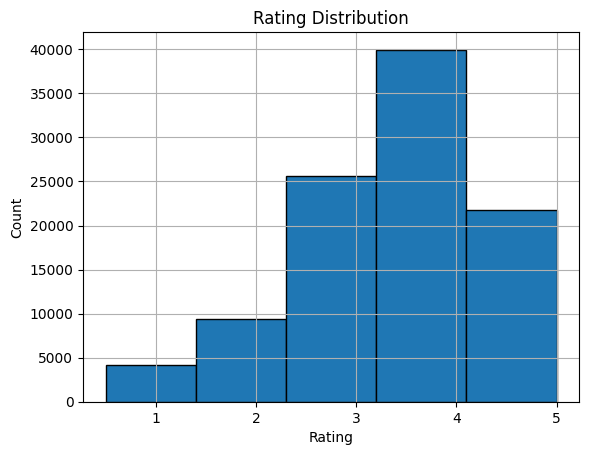

In [17]:
plot_rating_distribution()

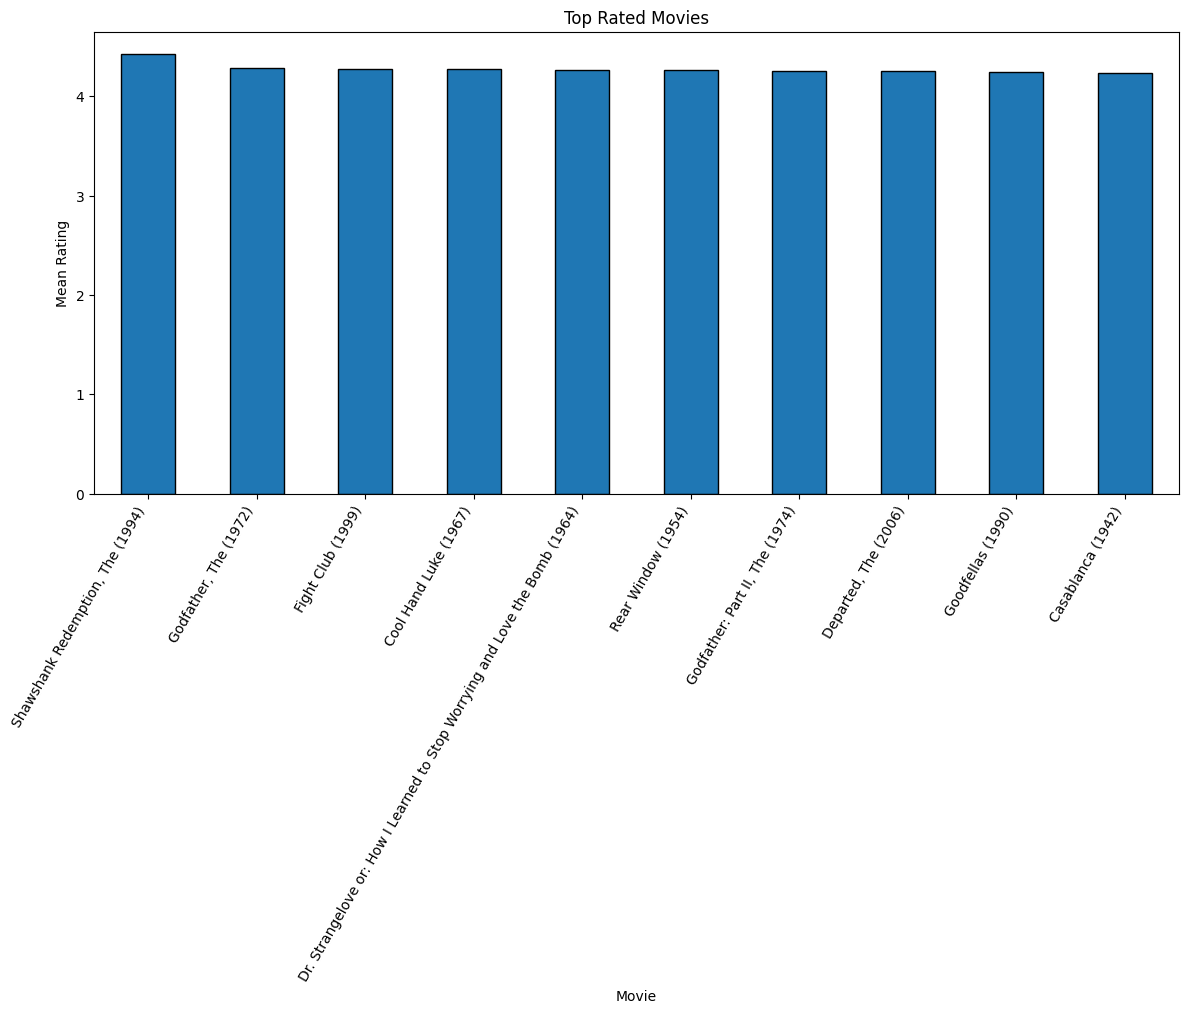

In [18]:
plot_top_movies()